In [14]:
import numpy as np
import pandas as pd
import random
from sklearn.linear_model import LogisticRegression
import sys

sys.path.insert(0, "../Modules")

pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

from utils import *

In [15]:
NUTS0 = 'IT'
NUTS2 = 'Veneto'

In [16]:
# f = open(f"data/{NUTS0}_WNV_{NUTS2}_cases_dates.txt", "r")
# print(f.read())

In [17]:
r_u = 0.05
near_u = 0.25
smote = 1
scaler = 'minmax'
#years_to_remove = [year for year in range(2012, 2018)]
years_to_remove = []
path = f'data/{NUTS0}_{NUTS2}_WNV_Dataset_2008-2019.csv'

In [18]:
dataset = read_data(path, exclude_years = years_to_remove)
dataset.head()

,x,y,dt_placement,municipality,district,region,municipality_enc,area,pop_1,pop_2,pop_3,pop_total,eq_distance,day,month,week,year,season,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,season_sin,season_cos,mosq_pred,mosq_prev_30d,case_prev_p,case_prev_m,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,hot_days_prev_30d,hot_days_from_newyear,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,case
0,12.02992,45.06869,2008-06-01,adria,rovigo,veneto,44,113.31867,7.735,8.768,2.317,18.82,46.64661,1,6,22,2008,3,0.201299,0.979530,1.224647e-16,-1.000000,0.464723,-0.885456,-1.0,-1.836970e-16,510,0,0,0,0.337618,0.085178,-0.258586,-0.085178,0.352347,0.100392,-0.258073,-0.100392,0.110758,0.113585,0.021746,0.113585,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,55.633333,96.800000,373.633333,6639.528847,1553.758894,2,122.991197,-1.277007,180.023385,0.0,1.404213,0
1,12.02992,45.06869,2008-06-16,adria,rovigo,veneto,44,113.31867,7.735,8.768,2.317,18.82,46.64661,16,6,25,2008,3,-0.101168,-0.994869,1.224647e-16,-1.000000,0.120537,-0.992709,-1.0,-1.836970e-16,435,510,0,0,0.610918,0.296090,-0.274469,-0.296090,0.593689,0.293090,-0.265909,-0.293090,0.064269,0.067268,0.022752,0.067268,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,64.500000,88.900000,462.533333,6639.528847,1553.758894,2,122.991197,-1.277007,180.023385,0.0,1.404213,0
2,12.02992,45.06869,2008-07-01,adria,rovigo,veneto,44,113.31867,7.735,8.768,2.317,18.82,46.64661,1,7,27,2008,3,0.201299,0.979530,-5.000000e-01,-0.866025,-0.120537,-0.992709,-1.0,-1.836970e-16,298,945,0,0,0.610918,0.296090,-0.274469,-0.296090,0.593689,0.293090,-0.265909,-0.293090,0.064269,0.067268,0.022752,0.067268,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,38.466667,58.666667,521.200000,6639.528847,1553.758894,2,122.991197,-1.277007,180.023385,0.0,1.404213,0
3,12.02992,45.06869,2008-07-16,adria,rovigo,veneto,44,113.31867,7.735,8.768,2.317,18.82,46.64661,16,7,29,2008,3,-0.101168,-0.994869,-5.000000e-01,-0.866025,-0.354605,-0.935016,-1.0,-1.836970e-16,370,733,0,0,0.610918,0.296090,-0.274469,-0.296090,0.593689,0.293090,-0.265909,-0.293090,0.064269,0.067268,0.022752,0.067268,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.100000,1.333333,522.533333,6639.528847,1553.758894,2,122.991197,-1.277007,180.023385,0.0,1.404213,0
4,12.02992,45.06869,2008-08-01,adria,rovigo,veneto,44,113.31867,7.735,8.768,2.317,18.82,46.64661,1,8,31,2008,3,0.201299,0.979530,-8.660254e-01,-0.500000,-0.568065,-0.822984,-1.0,-1.836970e-16,234,668,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,17.500000,32.033333,554.900000,6639.528847,1553.758894,2,122.991197,-1.277007,180.023385,0.0,1.404213,0


In [19]:
# dataset = dataset.query('month >= 6 & month <= 10')
# dataset.reset_index(inplace=True, drop=True)

dataset.rename(columns={"municipality": "lau1", "district": "nuts3", "region" : "nuts2", "municipality_enc" : "lau1_id"}, inplace=True)

In [20]:
dataset

,x,y,dt_placement,lau1,nuts3,nuts2,lau1_id,area,pop_1,pop_2,pop_3,pop_total,eq_distance,day,month,week,year,season,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,season_sin,season_cos,mosq_pred,mosq_prev_30d,case_prev_p,case_prev_m,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,hot_days_prev_30d,hot_days_from_newyear,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,case
0,12.02992,45.06869,2008-06-01,adria,rovigo,veneto,44,113.318670,7.735,8.768,2.317,18.82,46.64661,1,6,22,2008,3,0.201299,0.979530,1.224647e-16,-1.000000,0.464723,-0.885456,-1.0,-1.836970e-16,510,0,0,0,0.337618,0.085178,-0.258586,-0.085178,0.352347,0.100392,-0.258073,-0.100392,0.110758,0.113585,0.021746,0.113585,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,55.633333,96.800000,373.633333,6639.528847,1553.758894,2,122.991197,-1.277007,180.023385,0.0,1.404213,0
1,12.02992,45.06869,2008-06-16,adria,rovigo,veneto,44,113.318670,7.735,8.768,2.317,18.82,46.64661,16,6,25,2008,3,-0.101168,-0.994869,1.224647e-16,-1.000000,0.120537,-0.992709,-1.0,-1.836970e-16,435,510,0,0,0.610918,0.296090,-0.274469,-0.296090,0.593689,0.293090,-0.265909,-0.293090,0.064269,0.067268,0.022752,0.067268,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,64.500000,88.900000,462.533333,6639.528847,1553.758894,2,122.991197,-1.277007,180.023385,0.0,1.404213,0
2,12.02992,45.06869,2008-07-01,adria,rovigo,veneto,44,113.318670,7.735,8.768,2.317,18.82,46.64661,1,7,27,2008,3,0.201299,0.979530,-5.000000e-01,-0.866025,-0.120537,-0.992709,-1.0,-1.836970e-16,298,945,0,0,0.610918,0.296090,-0.274469,-0.296090,0.593689,0.293090,-0.265909,-0.293090,0.064269,0.067268,0.022752,0.067268,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,38.466667,58.666667,521.200000,6639.528847,1553.758894,2,122.991197,-1.277007,180.023385,0.0,1.404213,0
3,12.02992,45.06869,2008-07-16,adria,rovigo,veneto,44,113.318670,7.735,8.768,2.317,18.82,46.64661,16,7,29,2008,3,-0.101168,-0.994869,-5.000000e-01,-0.866025,-0.354605,-0.935016,-1.0,-1.836970e-16,370,733,0,0,0.610918,0.296090,-0.274469,-0.296090,0.593689,0.293090,-0.265909,-0.293090,0.064269,0.067268,0.022752,0.067268,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.100000,1.333333,522.533333,6639.528847,1553.758894,2,122.991197,-1.277007,180.023385,0.0,1.404213,0
4,12.02992,45.06869,2008-08-01,adria,rovigo,veneto,44,113.318670,7.735,8.768,2.317,18.82,46.64661,1,8,31,2008,3,0.201299,0.979530,-8.660254e-01,-0.500000,-0.568065,-0.822984,-1.0,-1.836970e-16,234,668,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,17.500000,32.033333,554.900000,6639.528847,1553.758894,2,122.991197,-1.277007,180.023385,0.0,1.404213,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22915,11.87360,45.40709,2018-08-16,padova,padova,veneto,86,92.983675,523.139,486.379,130.112,1139.63,46.93385,16,8,33,2018,3,-0.101168,-0.994869,-8.660254e-01,-0.500000,-0.748511,-0.663123,-1.0,-1.836970e-16,27,260,1,1,0.554525,0.210431,-0.480996,-0.210431,0.495450,0.152821,-0.434756,-0.152821,0.104371,0.075031,0.078626,0.075031,27.13,32.91,21.35,7.969862,0.685386,7.575429,-2.387659,15.673011,2.14352,26.639646,11.963797,1,1,48.833333,56.233333,546.200000,8095.541103,2727.375817,17,133.559342,17.254477,179.955010,0.0,1.000244,1
22916,11.87360,45.40709,2018-08-16,padova,padova,veneto,86,92.983675,523.139,486.379,130.112,1139.63,46.93385,16,8,33,2018,3,-0.101168,-0.994869,-8.660254e-01,-0.500000,-0.748511,-0.

In [21]:
dsc = dataframe_describe(dataset)
dsc.head(15)

,year,non-case,case,total,percentage
0,2008,1907,1,1908,8.32%
1,2009,1902,6,1908,8.32%
2,2010,1901,7,1908,8.32%
3,2011,1897,11,1908,8.32%
4,2012,1877,34,1911,8.34%
5,2013,1880,29,1909,8.33%
6,2014,1906,2,1908,8.32%
7,2015,1907,1,1908,8.32%
8,2016,1896,12,1908,8.32%
9,2017,1892,17,1909,8.33%


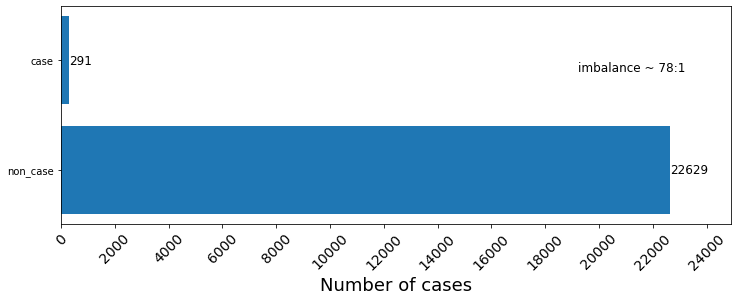

In [22]:
plot_imbalance(dataset)

In [23]:
coefficients = []
results_train = pd.DataFrame()
results_test = pd.DataFrame()
feature_names = dataset.select_dtypes(exclude=['object']).drop(columns = ['case']).columns

In [24]:
for train_idx, test_idx in yearCV_split(dataset):
    data_train = dataset.iloc[train_idx]
    data_test = dataset.iloc[test_idx]
    
    data_train.reset_index(inplace = True, drop = True)
    data_test.reset_index(inplace = True, drop = True)
    
    X_train = data_train.select_dtypes(exclude=['object']).drop(columns = ['case'])
    y_train = data_train['case']
    X_test = data_test.select_dtypes(exclude=['object']).drop(columns = ['case'])
    y_test = data_test['case']
    
    X_train, X_test, y_train, y_test, X_train_df = transform_data(X_train, X_test, y_train, y_test, r_u, near_u, smote, scaler_key=scaler)
    
    w0,w1 = calculate_weights(y_train)

    model = LogisticRegression(max_iter = 1000, class_weight = {0.0: w0, 1.0:w1}, n_jobs = -1, random_state = 0)
    
    train, test, coef = train_and_predict(model, X_train_df, data_test, X_train, y_train, X_test, y_test)
    
    results_train = results_train.append(train, ignore_index = True)
    results_test = results_test.append(test, ignore_index = True)
    coefficients.append(coef)
    
    print(f"Year: {test['year'].iloc[0]} || w0:{w0}, w1:{w1} || ##")

Year: 2008 || w0:1, w1:27 || ##
Year: 2009 || w0:1, w1:27 || ##
Year: 2010 || w0:1, w1:28 || ##
Year: 2011 || w0:1, w1:28 || ##
Year: 2012 || w0:1, w1:30 || ##
Year: 2013 || w0:1, w1:30 || ##
Year: 2014 || w0:1, w1:27 || ##
Year: 2015 || w0:1, w1:27 || ##
Year: 2016 || w0:1, w1:28 || ##
Year: 2017 || w0:1, w1:28 || ##
Year: 2018 || w0:1, w1:50 || ##
Year: 2019 || w0:1, w1:31 || ##


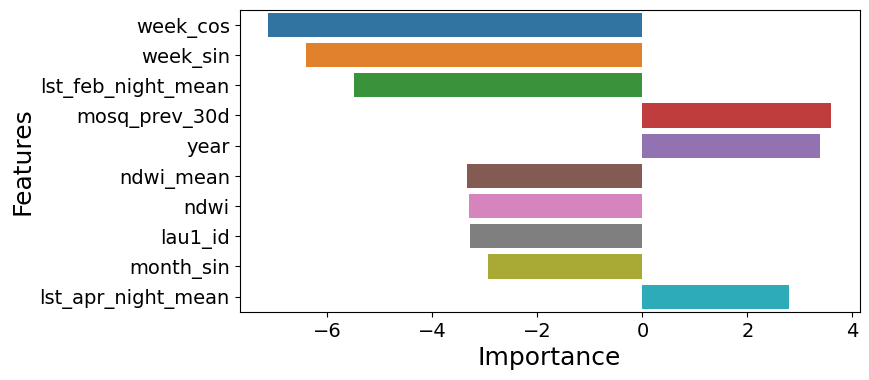

In [25]:
plot_feature_importance(coefficients, feature_names, top = 10, figure_size = (8, 4))

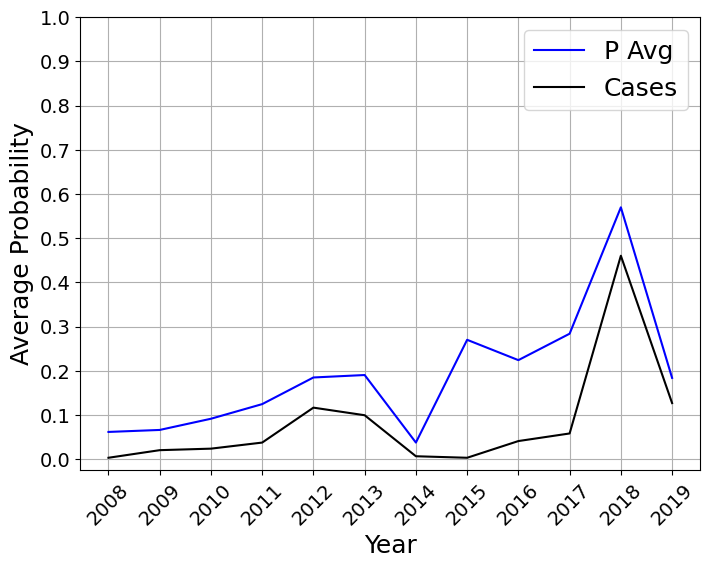

In [26]:
plot_trend_curve(results_test, list(dsc['case']))

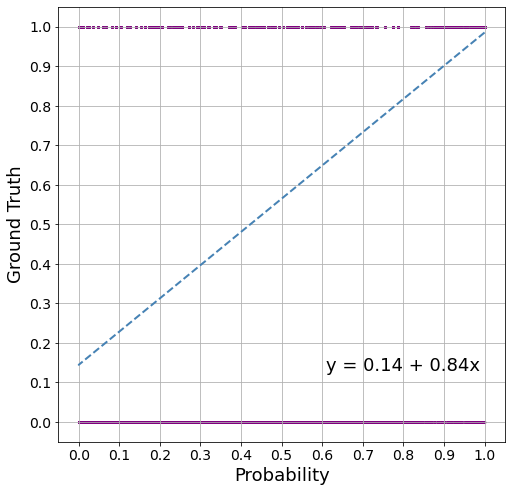

In [27]:
plot_probability_curve(results_test)

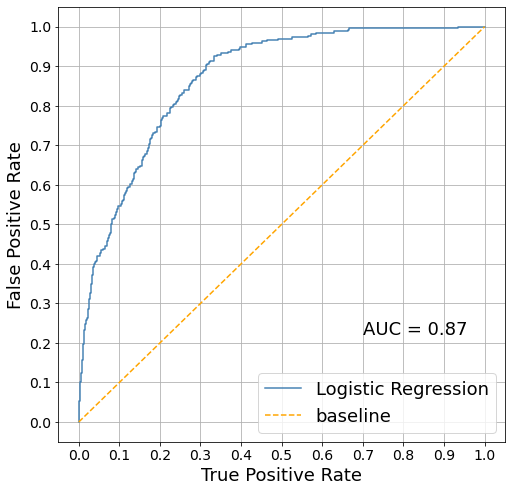

In [28]:
plot_roc_curve(results_test)

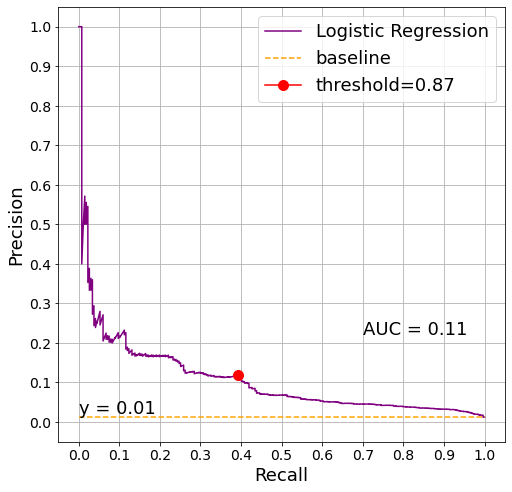

In [29]:
plot_pr_curve(results_test, plot_fbeta = True)

In [35]:
operational, cumulative, avg, weighted = evaluate_operational(results_test, k = 10, prob_threshold = -1)
print(f'Average: {avg*100:.2f}%\nWeighted Average: {weighted*100:.2f}%')

Average: 7.73%
Weighted Average: 14.91%


In [36]:
operational

,Prediction Date,Infected,Discovered,Out of,Percentage,percentage
0,01/06/2008,0,0,0,NaN,NaN
1,16/06/2008,0,0,0,NaN,NaN
2,01/07/2008,0,0,0,NaN,NaN
3,16/07/2008,0,0,0,NaN,NaN
4,01/08/2008,0,0,0,NaN,NaN
...,...,...,...,...,...,...
139,16/09/2019,5,0,5,0.00 %,0.0
140,01/10/2019,1,0,1,0.00 %,0.0
141,16/10/2019,0,0,0,NaN,NaN
142,01/11/2019,0,0,0,NaN,NaN


In [37]:
cumulative

,Year,Infected,Discovered,Out Of,Percentage,percentage
0,2008,1,0,1,0.00 %,0.0000
1,2009,6,0,6,0.00 %,0.0000
2,2010,7,1,7,14.29 %,0.1429
3,2011,11,2,11,18.18 %,0.1818
4,2012,31,4,29,13.79 %,0.1379
5,2013,28,3,25,12.00 %,0.1200
6,2014,2,0,2,0.00 %,0.0000
7,2015,1,0,1,0.00 %,0.0000
8,2016,12,1,12,8.33 %,0.0833
9,2017,16,0,16,0.00 %,0.0000


In [38]:
report_train, report_test = classification_report(results_train, results_test, threshold = 0.2, beta = 4)

In [39]:
report_test.head(15)

,Year,Infected,Positive Rate,Accuracy,Precision,Recall,F4 Score,Loss
0,2008,1.00,0.0870,0.9567,0.0060,1.0000,0.0934,0.0709
1,2009,6.00,0.1095,0.5287,0.0048,0.1667,0.0557,0.0847
2,2010,7.00,0.1735,0.6280,0.0091,0.4286,0.1151,0.1202
3,2011,11.00,0.2490,0.7405,0.0168,0.7273,0.2089,0.1673
4,2012,31.00,0.3726,0.7861,0.0408,0.9355,0.4085,0.2584
5,2013,28.00,0.3826,0.7952,0.0370,0.9643,0.3896,0.2711
6,2014,2.00,0.0304,0.4848,0.0000,0.0000,0.0000,0.0441
7,2015,1.00,0.4418,0.7792,0.0012,1.0000,0.0198,0.4355
8,2016,12.00,0.3889,0.8075,0.0162,1.0000,0.2184,0.3399
9,2017,16.00,0.4565,0.7425,0.0172,0.9375,0.2263,0.4779
